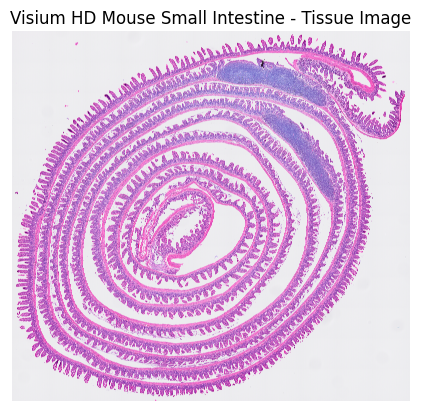

In [7]:
import cv2
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt

# Path to the tissue image file
image_path = "/kaggle/input/visium-hd-mouse-small-intestine-2folders/MasterDataset/Visium_HD_Mouse_Small_Intestine_tissue_image.btf"

# Load the image
tissue_image = iio.imread(image_path)

# Display the image
plt.imshow(tissue_image, cmap="gray")
plt.title("Visium HD Mouse Small Intestine - Tissue Image")
plt.axis("off")
plt.show()


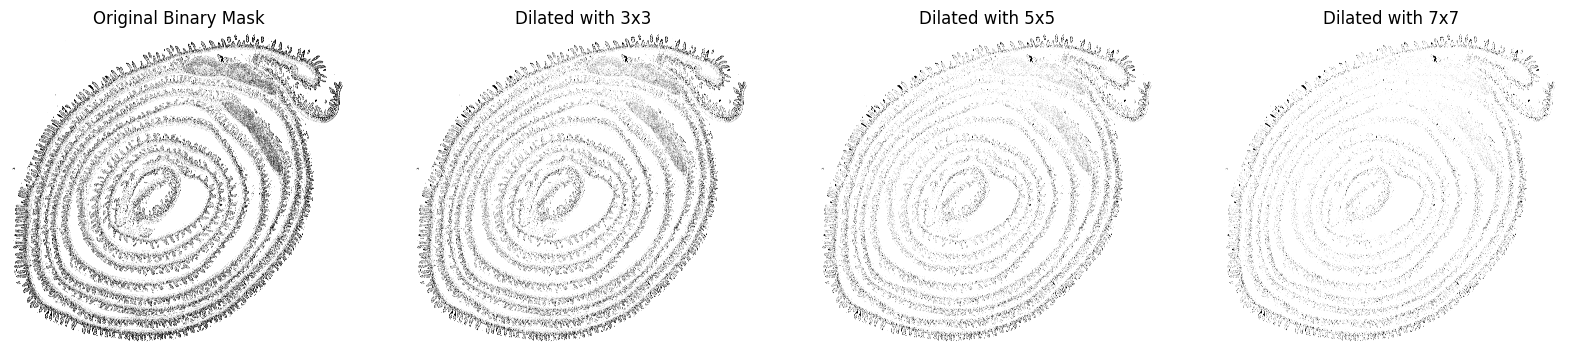

In [8]:
# Convert to grayscale (if needed)
gray_image = cv2.cvtColor(tissue_image, cv2.COLOR_RGB2GRAY)

# Apply thresholding to create a binary mask
_, binary_mask = cv2.threshold(gray_image, 128, 255, cv2.THRESH_BINARY)

# Define structuring elements for dilation
kernel_3x3 = np.ones((3,3), np.uint8)
kernel_5x5 = np.ones((5,5), np.uint8)
kernel_7x7 = np.ones((7,7), np.uint8)

# Apply dilation with different kernel sizes
dilated_3x3 = cv2.dilate(binary_mask, kernel_3x3, iterations=1)
dilated_5x5 = cv2.dilate(binary_mask, kernel_5x5, iterations=1)
dilated_7x7 = cv2.dilate(binary_mask, kernel_7x7, iterations=1)

# Display the results
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(binary_mask, cmap='gray')
ax[0].set_title("Original Binary Mask")
ax[1].imshow(dilated_3x3, cmap='gray')
ax[1].set_title("Dilated with 3x3")
ax[2].imshow(dilated_5x5, cmap='gray')
ax[2].set_title("Dilated with 5x5")
ax[3].imshow(dilated_7x7, cmap='gray')
ax[3].set_title("Dilated with 7x7")
for a in ax: a.axis("off")
plt.show()


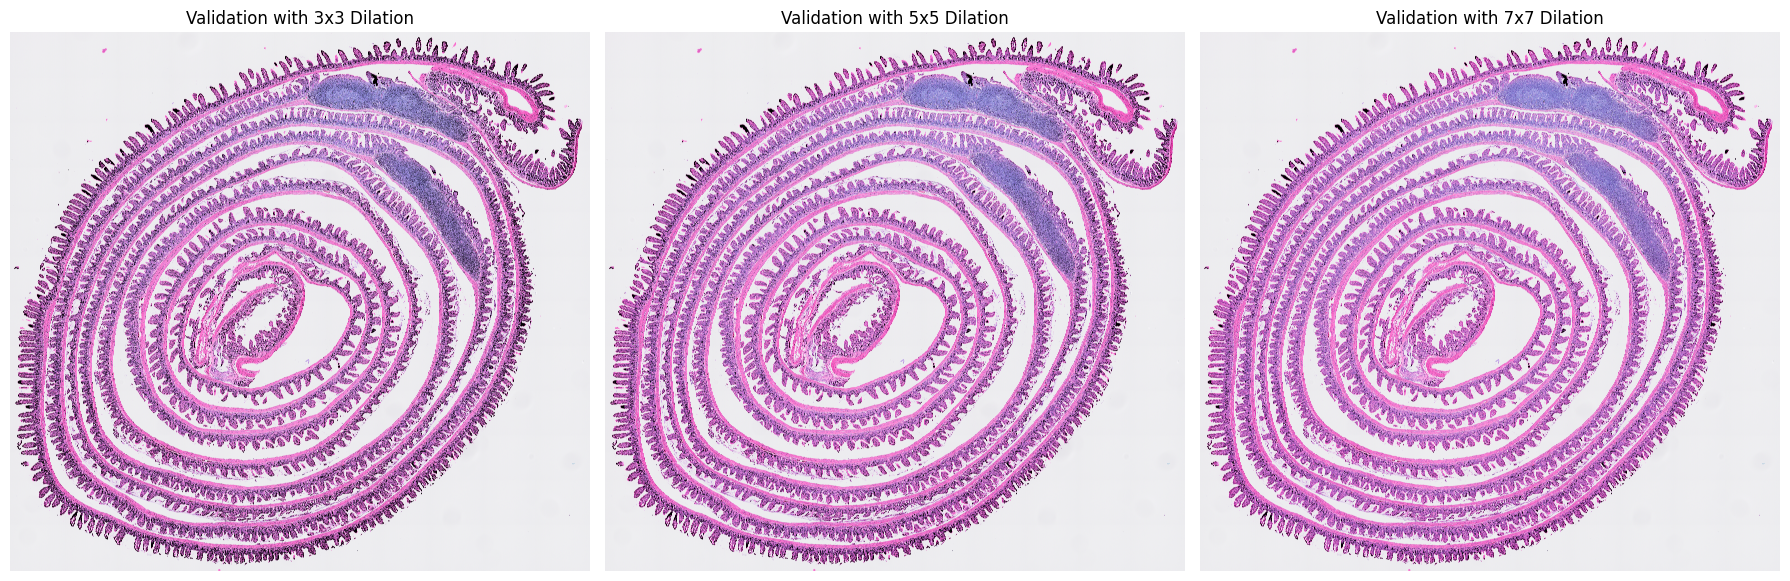

In [9]:
# Multiply the original image (grayscale) by the binary mask
validation_3x3 = cv2.bitwise_and(tissue_image, tissue_image, mask=dilated_3x3)
validation_5x5 = cv2.bitwise_and(tissue_image, tissue_image, mask=dilated_5x5)
validation_7x7 = cv2.bitwise_and(tissue_image, tissue_image, mask=dilated_7x7)

# Display the results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(validation_3x3, cmap='gray')
ax[0].set_title("Validation with 3x3 Dilation")
ax[1].imshow(validation_5x5, cmap='gray')
ax[1].set_title("Validation with 5x5 Dilation")
ax[2].imshow(validation_7x7, cmap='gray')
ax[2].set_title("Validation with 7x7 Dilation")

for a in ax: a.axis("off")
plt.tight_layout()
plt.show()